In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)


In [4]:
vw = pd.read_csv("volkswagen.csv")
honda = pd.read_csv("honda.csv")

print("VW shape:", vw.shape)
print("Honda shape:", honda.shape)

vw.head()


VW shape: (4, 4)
Honda shape: (5, 1)


,Model,Year,Price,Electric
0,Golf,2020,23000,False
1,Passat,2021,28000,False
2,Polo,2019,18000,False
3,Tiguan,2022,32000,False


In [5]:
vw["brand"] = "Volkswagen"
honda["brand"] = "Honda"


In [6]:
df = pd.concat([vw, honda], ignore_index=True)

df.head()


,Model,Year,Price,Electric,brand,Model Year Price
0,Golf,2020.0,23000.0,False,Volkswagen,NaN
1,Passat,2021.0,28000.0,False,Volkswagen,NaN
2,Polo,2019.0,18000.0,False,Volkswagen,NaN
3,Tiguan,2022.0,32000.0,False,Volkswagen,NaN
4,NaN,NaN,NaN,NaN,Honda,0 Civic 2020 22000


In [8]:
import pandas as pd

# Clean column names (removes spaces and makes lowercase)
df.columns = df.columns.str.strip().str.lower()

# List of numeric columns
numeric_cols = [
    "units_sold",
    "revenue",
    "cost",
    "profit",
    "customer_age",
    "customer_income"
]

# Convert numeric columns safely
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Convert date column safely
if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
else:
    print("Warning: 'date' column not found.")
    print("Available columns:", df.columns.tolist())

# Optional: check results
print(df.info())
print(df.head())



Available columns: ['model', 'year', 'price', 'electric', 'brand', 'model  year  price']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   model               4 non-null      object 
 1   year                4 non-null      float64
 2   price               4 non-null      float64
 3   electric            4 non-null      object 
 4   brand               9 non-null      object 
 5   model  year  price  5 non-null      object 
dtypes: float64(2), object(4)
memory usage: 564.0+ bytes
None
    model    year    price electric       brand      model  year  price
0    Golf  2020.0  23000.0    False  Volkswagen                     NaN
1  Passat  2021.0  28000.0    False  Volkswagen                     NaN
2    Polo  2019.0  18000.0    False  Volkswagen                     NaN
3  Tiguan  2022.0  32000.0    False  Volkswagen                     N

In [13]:
print(df.columns)


Index(['model', 'year', 'price', 'electric', 'brand', 'model  year  price'], dtype='object')


In [16]:
for col in df.columns:
    print(repr(col))



'model'
'year'
'price'
'electric'
'brand'
'model__year__price'


In [21]:
import matplotlib.pyplot as plt

# Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Find column containing "age"
age_column = None
for col in df.columns:
    if "age" in col:
        age_column = col
        break

# Check if found
if age_column is None:
    print("No age column found. Columns are:", df.columns)
else:
    print("Using column:", age_column)
    
    age_comparison = df.groupby("brand")[age_column].mean()
    
    age_comparison.plot(kind="bar", title="Average Customer Age")
    
    plt.show()
    
    print(age_comparison)





No age column found. Columns are: Index(['model', 'year', 'price', 'electric', 'brand', 'model__year__price'], dtype='object')


In [26]:
print(df.columns.tolist())
print(df.head())





['model', 'year', 'price', 'electric', 'brand', 'model__year__price']
    model    year    price electric       brand      model__year__price
0    Golf  2020.0  23000.0    False  Volkswagen                     NaN
1  Passat  2021.0  28000.0    False  Volkswagen                     NaN
2    Polo  2019.0  18000.0    False  Volkswagen                     NaN
3  Tiguan  2022.0  32000.0    False  Volkswagen                     NaN
4     NaN     NaN      NaN      NaN       Honda  0   Civic  2020  22000


In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Print columns so you can see them
print("Available columns:", df.columns.tolist())

# Automatically find the income column
income_col = None
for col in df.columns:
    if "income" in col:
        income_col = col
        break

# Check if found
if income_col is None:
    print("No income column found.")
else:
    print(f"Using income column: {income_col}")
    
    # Group by brand and calculate median income
    income = df.groupby("brand")[income_col].median()
    
    # Plot
    income.plot(kind="bar", title="Median Customer Income")
    plt.xlabel("Brand")
    plt.ylabel("Median Income")
    plt.show()



Available columns: ['model', 'year', 'price', 'electric', 'brand', 'model__year__price']
No income column found.


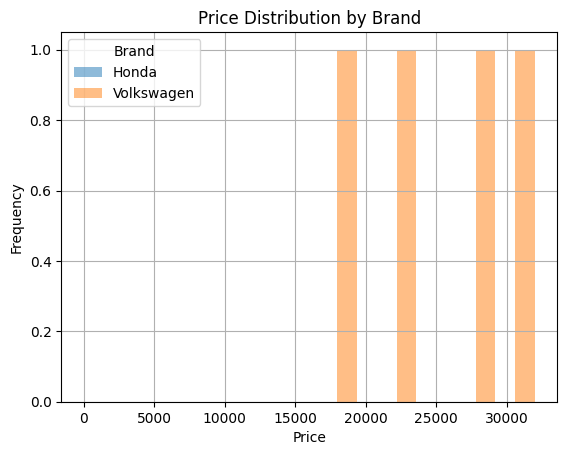

In [35]:
import matplotlib.pyplot as plt

# Clean column names
df.columns = df.columns.str.strip().str.lower()

# Plot price distribution by brand
plt.figure()

for brand, group in df.groupby("brand"):
    group["price"].dropna().hist(alpha=0.5, label=brand)

plt.title("Price Distribution by Brand")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.legend(title="Brand")

plt.show()



In [39]:
# Import pandas
import pandas as pd

# Load dataset
df = pd.read_csv("cars.csv")

# Show columns
print("Columns in dataset:")
print(df.columns.tolist())

# Filter Volkswagen and Honda
filtered = df[df["Make"].isin(["Volkswagen", "Honda"])]

# Select only numeric columns automatically
numeric_cols = filtered.select_dtypes(include="number").columns

# Create summary
summary = filtered.groupby("Make")[numeric_cols].mean()

# Show summary
print("\nSummary comparison:")
print(summary)

# Save to CSV
summary.to_csv("vw_vs_honda_comparison.csv")

print("\nFile saved successfully as vw_vs_honda_comparison.csv")


Columns in dataset:
['YEAR', 'Make', 'Model', 'Size', '(kW)', 'Unnamed: 5', 'TYPE', 'CITY (kWh/100 km)', 'HWY (kWh/100 km)', 'COMB (kWh/100 km)', 'CITY (Le/100 km)', 'HWY (Le/100 km)', 'COMB (Le/100 km)', '(g/km)', 'RATING', '(km)', 'TIME (h)']

Summary comparison:
Empty DataFrame
Columns: [YEAR, (kW), CITY (kWh/100 km), HWY (kWh/100 km), COMB (kWh/100 km), CITY (Le/100 km), HWY (Le/100 km), COMB (Le/100 km), (g/km), RATING, (km), TIME (h)]
Index: []

File saved successfully as vw_vs_honda_comparison.csv
